In [237]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math
import warnings
import re

## Configuration


### Path Configuration


In [238]:
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251120_11-00-03").resolve()
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251121_23-09-00").resolve()
TOPOLOGY_FOLDER_TO_ANALYZE = "random_20N"

### Log File Names


In [239]:
PDR_LOG_FILE = "log_PDR.csv"
LATENCY_LOG_FILE = "log_e2eLat.csv"
PARENT_CHG_LOG_FILE = "log_ParChg.csv"
APP_LOG_FILE = "log_app.csv"
PARAMETERS_FILE = "parameters.txt"
IT_FILE = "log_IT.csv"

### Plot Style


In [240]:
# Time window size (in seconds) to aggregate parent changes
TIME_BIN_SIZE_S = 5.0

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

## Helpers Functions


In [241]:
def process_pdr_file(file_path):
    """Reads PDR file and returns the mean PDR of that run."""
    try:
        df = pd.read_csv(file_path, skipinitialspace=True)
        if df.empty or "delivered" not in df.columns:
            return None
        return df.drop("Unnamed: 0", axis=1, errors="ignore")
    except Exception:
        return pd.DataFrame(columns=["delivered"])


def get_interarrivals(file_path):
    """Reads App Log file and returns the mean inter-arrival time."""
    df = pd.read_csv(file_path, skipinitialspace=True)

    df = df[df["event"].isin(["SEND", "SEND_FAIL"])]

    df = df.sort_values(by="time")
    df["inter_arrival"] = df.groupby("node_id")["time"].diff().fillna(0)

    return df


def process_latency_file(file_path):
    """Reads Latency file and returns a list of latency values."""
    try:
        df = pd.read_csv(file_path, skipinitialspace=True)
        if df.empty or "latency" not in df.columns:
            return []
        return df["latency"].tolist()
    except Exception:
        return []


def get_simulation_parameters(file_path):
    """Reads Simulation Parameters file (.txt) and returns a dictionary of parameters."""
    regex = r"^(.*): (.*)$"  # Regex to match "Parameter: Value" lines
    params = {}
    try:
        with open(file_path, "r") as f:
            for line in f:
                match = re.match(regex, line.strip())
                if match:
                    key = match.group(1).strip()
                    value = match.group(2).strip()
                    params[key] = value
    except Exception:
        pass
    return params


def process_parent_change_files(file_paths, bin_size=1.0):
    """
    Aggregates parent change events over time across multiple runs.

    Returns:
        bin_centers (np.array): The time axis.
        mean_counts (np.array): Average parent changes per bin.
    """
    if not file_paths:
        return None, None

    all_histograms = []
    max_time = 0

    # First pass: Determine max simulation time to define bins common to all runs
    for fp in file_paths:
        try:
            df = pd.read_csv(fp, skipinitialspace=True)
            if not df.empty and "timestamp" in df.columns:
                local_max = df["timestamp"].max()
                if local_max > max_time:
                    max_time = local_max
        except Exception:
            continue

    if max_time == 0:
        return None, None

    # Define bins
    bins = np.arange(0, math.ceil(max_time) + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Second pass: Histogram the data for each run
    valid_runs = 0
    for fp in file_paths:
        try:
            df = pd.read_csv(fp, skipinitialspace=True)
            if df.empty or "timestamp" not in df.columns:
                continue

            # Count events in each time bin
            counts, _ = np.histogram(df["timestamp"], bins=bins)
            all_histograms.append(counts)
            valid_runs += 1
        except Exception:
            continue

    if valid_runs == 0:
        return None, None

    # Stack arrays: shape (num_runs, num_bins)
    data_matrix = np.vstack(all_histograms)

    # Calculate Statistics (ONLY MEAN, NO CI)
    mean_counts = np.mean(data_matrix, axis=0)

    return bin_centers, mean_counts

## Main Analysis Batch 20251120_11-00-03


In [242]:
analysis_base_path = PATH_TO_RESULTS_PARENT_FOLDER / TOPOLOGY_FOLDER_TO_ANALYZE

if not analysis_base_path.exists():
    print(f"CRITICAL ERROR: Path does not exist: {analysis_base_path}")
    sys.exit(1)

print(f"Analyizing Topology: {TOPOLOGY_FOLDER_TO_ANALYZE}")

# 1. Discover Configurations (subfolders)
configs = sorted([d for d in analysis_base_path.iterdir() if d.is_dir()])
if not configs:
    print("No configuration folders found.")
    sys.exit(0)

results = pd.DataFrame(
    columns=[
        "configuration",
        "seed",
        "pdr",
        "latency",
        "par_changes",
        "mean_interarrival",
        "true_mean_interarrival",
    ]
)

rows = []

# --- DATA COLLECTION PHASE ---
print("Collecting data from files...")
for config_dir in configs:
    config_name = config_dir.name
    print(f"  > Processing config: {config_name}")

    seed_dirs = sorted([d for d in config_dir.iterdir() if d.is_dir()])

    for seed in seed_dirs:
        repetition_data = {
            "configuration": config_name,
            "seed": seed.name,
            "mean_interarrival": get_interarrivals(seed / APP_LOG_FILE)[
                "inter_arrival"
            ].mean(),
            "true_mean_interarrival": float(
                get_simulation_parameters(seed / PARAMETERS_FILE)["mean_interarrival"]
            ),
        }

        # PDR
        p = process_pdr_file(seed / PDR_LOG_FILE)["delivered"].mean()
        repetition_data["pdr"] = p

        # Latency
        l = process_latency_file(seed / LATENCY_LOG_FILE)
        repetition_data["latency"] = np.mean(l) if l else None

        # Parent Changes (Store path only, process later)
        pc_file = seed / PARENT_CHG_LOG_FILE
        repetition_data["par_changes"] = pc_file

        rows.append(repetition_data)

results = pd.DataFrame(rows)

Analyizing Topology: random_20N
  > Processing config: ideal
  > Processing config: lossy
  > Processing config: stable
  > Processing config: stable_high_pl
  > Processing config: stable_mid_pl
  > Processing config: unstable


### Adjust NaN values in results DataFrame

In [ ]:
results["pdr"] = results["pdr"].fillna(0)

Are there any NaN values in any column of the results DataFrame?

In [ ]:
print(results.isna().sum())

configuration              0
seed                       0
mean_interarrival          0
true_mean_interarrival     0
pdr                        0
latency                   39
par_changes                0
dtype: int64


In [ ]:
results

,configuration,seed,mean_interarrival,true_mean_interarrival,pdr,latency,par_changes
0,ideal,12345,59.986209,60.0,0.984991,0.008549,/home/simone/uni/spe/SPE-project/results/batch...
1,ideal,12345_antithetic,54.289619,60.0,0.921769,0.008105,/home/simone/uni/spe/SPE-project/results/batch...
2,ideal,12346,53.066403,60.0,0.973378,0.008519,/home/simone/uni/spe/SPE-project/results/batch...
3,ideal,12346_antithetic,62.459145,60.0,0.944664,0.009136,/home/simone/uni/spe/SPE-project/results/batch...
4,ideal,12347,57.775183,60.0,0.972777,0.008012,/home/simone/uni/spe/SPE-project/results/batch...
...,...,...,...,...,...,...,...
595,unstable,12392_antithetic,55.531176,60.0,0.175824,0.009655,/home/simone/uni/spe/SPE-project/results/batch...
596,unstable,12393,54.136835,60.0,0.103448,0.017625,/home/simone/uni/spe/SPE-project/results/batch...
597,unstable,12393_antithetic,56.006149,60.0,0.191257,0.016847,/home/simone/uni/spe/SPE-project/results/batch...
598,unstable,12394,54.848554,60.0,0.321429,0.015724,/home/simone/uni/spe/SPE-project/results/batch...


## Evaluation of Correlation between IT and PDR inside a Single Run

In order to understand if it is better to use the singe values of the simulation (instead of a single metric per run) for the control variate technique, we need to evaluate if there is a correlation between the inter-arrival times and the packet delivery results.

In [243]:
simulation_path = (
    PATH_TO_RESULTS_PARENT_FOLDER
    / TOPOLOGY_FOLDER_TO_ANALYZE
    / Path("lossy")
    / Path("12385_antithetic")
)

interarrivals_df = get_interarrivals(simulation_path / APP_LOG_FILE)
pdrs = process_pdr_file(simulation_path / PDR_LOG_FILE)

# len(pdrs), len(interarrivals_df)
interarrivals_df["source"] = (
    interarrivals_df["node_id"]
    .dropna()
    .str.replace("Node-", "", regex=False)
    .map(lambda x: f"{int(x):04x}")
)

print(pdrs)
interarrivals_df

    source_addr  seq_num dest_addr  delivered
0          0011        1      0003          0
1          0003        1      0006          1
2          0003        2      0012          0
3          000d        1      0002          0
4          000b        1      0004          1
..          ...      ...       ...        ...
500        000b       28      000c          0
501        0007       22      000d          1
502        0009       33      000f          1
503        000b       29      0014          0
504        0014       25      0008          0

[505 rows x 4 columns]


,time,event,node_id,type,seq_num,dest,source,hops,reason,inter_arrival
21,130.233432,SEND,Node-17,DATA,1.0,0003,0011,NaN,NaN,0.000000
23,130.372490,SEND,Node-3,DATA,1.0,0006,0003,NaN,NaN,0.000000
25,131.869299,SEND,Node-3,DATA,2.0,0012,0003,NaN,NaN,1.496809
27,133.974070,SEND,Node-13,DATA,1.0,0002,000d,NaN,NaN,0.000000
29,134.517632,SEND,Node-11,DATA,1.0,0004,000b,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
855,1797.064951,SEND,Node-11,DATA,28.0,000c,000b,NaN,NaN,5.255804
856,1798.268788,SEND,Node-7,DATA,22.0,000d,0007,NaN,NaN,75.038073
858,1799.365659,SEND,Node-9,DATA,33.0,000f,0009,NaN,NaN,128.318458
860,1799.432215,SEND,Node-11,DATA,29.0,0014,000b,NaN,NaN,2.367264


In [244]:
inter_df = interarrivals_df.rename(
    columns={
        "source": "source_addr",
        "dest": "dest_addr",
        "seq_num": "seq_num",
    }
)

pdrs_df = pdrs.rename(
    columns={
        "source_addr": "source_addr",
        "dest_addr": "dest_addr",
        "seq_num": "seq_num",
    }
)

In [245]:
inter_df["source_addr"] = inter_df["source_addr"].astype(str)
inter_df["dest_addr"] = inter_df["dest_addr"].astype(str)
inter_df["seq_num"] = inter_df["seq_num"].astype(int)

pdrs_df["source_addr"] = pdrs_df["source_addr"].astype(str)
pdrs_df["dest_addr"] = pdrs_df["dest_addr"].astype(str)
pdrs_df["seq_num"] = pdrs_df["seq_num"].astype(int)

In [246]:
joined = inter_df.merge(
    pdrs_df,
    on=["source_addr", "dest_addr", "seq_num"],
    how="outer",
    indicator=True,
    suffixes=("_send", "_pdr"),
)

In [247]:
unmatched = joined[joined["_merge"] != "both"]
print(unmatched["_merge"].value_counts())

_merge
left_only     75
right_only     0
both           0
Name: count, dtype: int64


In [248]:
missing_pdr = joined[joined["_merge"] == "left_only"]

In [249]:
missing_interarrival = joined[joined["_merge"] == "right_only"]

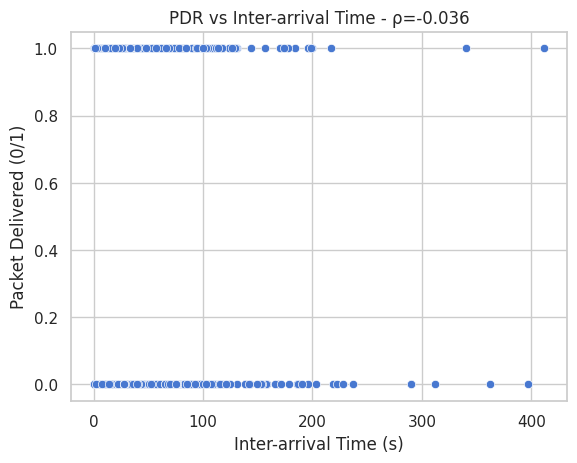

In [250]:
joined = joined[joined["_merge"] == "both"]

sns.scatterplot(
    data=joined,
    x="inter_arrival",
    y="delivered",
)
plt.xlabel("Inter-arrival Time (s)")
plt.ylabel("Packet Delivered (0/1)")
plt.title(f"PDR vs Inter-arrival Time - ρ={np.corrcoef(joined['inter_arrival'], joined['delivered'])[0,1]:.3f}")
plt.show()

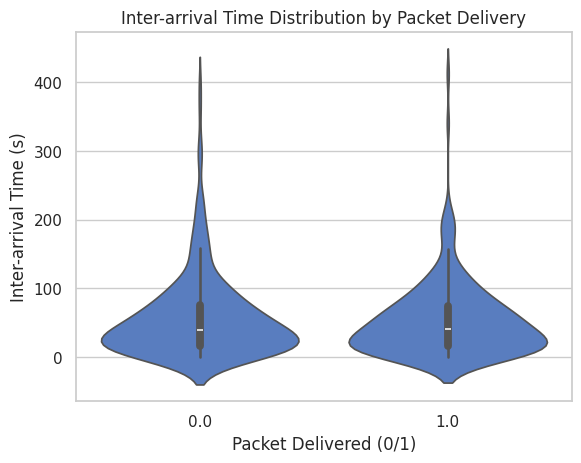

In [251]:
sns.violinplot(
    data=joined,
    x="delivered",
    y="inter_arrival",
)
plt.xlabel("Packet Delivered (0/1)")
plt.ylabel("Inter-arrival Time (s)")
plt.title("Inter-arrival Time Distribution by Packet Delivery")
plt.show()


In [255]:
def compute_optimal_beta(
    metrics: list,
    control_vars: list,
) -> float:
    """
    Computes the optimal beta coefficient for Control Variates.

    Args:
        metrics (list): List of metric values (Y).
        control_vars (list): List of control variable values (X).

    Returns:
        beta (float): Optimal beta coefficient.
    """
    Y = np.array(metrics)
    X = np.array(control_vars)
    assert len(Y) == len(X), "Metrics and control variables must have the same length."
    assert len(Y) > 1, "At least two data points are required."

    cov_YX = np.cov(Y, X, ddof=1)[0, 1]
    var_X = np.var(X, ddof=1)
    assert not math.isnan(cov_YX), "Covariance computation resulted in NaN."
    assert not math.isnan(var_X), "Variance computation resulted in NaN."
    assert var_X != 0, "Variance of control variable X is zero."

    beta = cov_YX / var_X

    return beta


def cvariance_reduction(
    metrics: list,
    control_vars: list,
    true_control_mean: float,
    beta: float | None = None,
) -> float:
    """
    Applies Control Variates variance reduction technique.

    Args:
        metrics (list): List of metric values (Y).
        control_vars (list): List of control variable values (X).
        true_control_mean (float): True mean of the control variable (mu_X).
        beta (float | None): Precomputed beta coefficient. If None, it will be computed.

    Returns:
        Y_cv (float): Control variate adjusted mean.
    """
    Y = np.array(metrics)
    X = np.array(control_vars)

    Y_mean = np.mean(Y)
    X_mean = np.mean(X)

    if beta is None:
        beta = compute_optimal_beta(metrics, control_vars)

    Y_cv = Y_mean - beta * (X_mean - true_control_mean)

    return Y_cv

In [256]:
CONFIG_TO_ANALYZE = "lossy"
REPETITIONS = 1000
SAMPLE_SIZE = 0.8
METRIC_TO_ANALYZE = "pdr"

config_results = results[results["configuration"] == CONFIG_TO_ANALYZE]

cv_metric = []
raw_metric = []

optimal_beta = compute_optimal_beta(
    metrics=config_results[METRIC_TO_ANALYZE].tolist(),
    control_vars=config_results["mean_interarrival"].tolist(),
)

for _ in range(REPETITIONS):
    sample = config_results.sample(frac=SAMPLE_SIZE, replace=True, random_state=None)

    raw_mean_pdr = sample[METRIC_TO_ANALYZE].mean()
    raw_metric.append(raw_mean_pdr)

    cv_mean_metric = cvariance_reduction(
        metrics=sample[METRIC_TO_ANALYZE].tolist(),
        control_vars=sample["mean_interarrival"].tolist(),
        true_control_mean=sample["true_mean_interarrival"].iloc[0],
        beta=optimal_beta,
    )
    cv_metric.append(cv_mean_metric)

assert len(raw_metric) == len(cv_metric) == REPETITIONS
assert config_results["true_mean_interarrival"].nunique() == 1
assert config_results["true_mean_interarrival"].iloc[0] == 60.0

In [257]:
print(np.corrcoef(
    config_results[METRIC_TO_ANALYZE],
    config_results["mean_interarrival"]
)[0, 1])

-0.21066340653338095


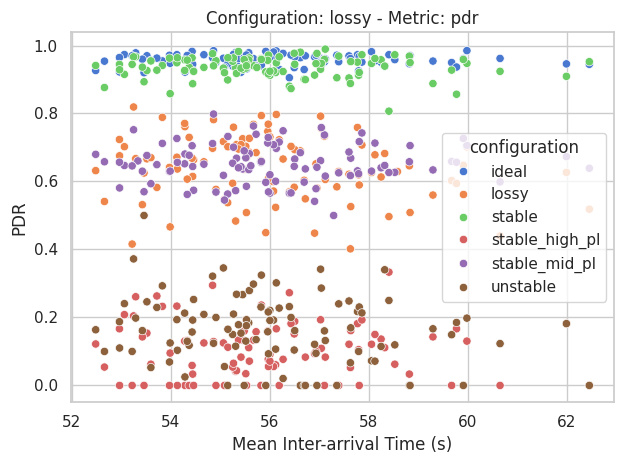

In [258]:
sns.scatterplot(data=results, x="mean_interarrival", y=METRIC_TO_ANALYZE, hue="configuration")
plt.title(f"Configuration: {CONFIG_TO_ANALYZE} - Metric: {METRIC_TO_ANALYZE}")
plt.xlabel("Mean Inter-arrival Time (s)")
plt.ylabel(METRIC_TO_ANALYZE.upper())
plt.tight_layout()
plt.show()

> [!warning]
> The following code cell is not really something significant for the analysis.

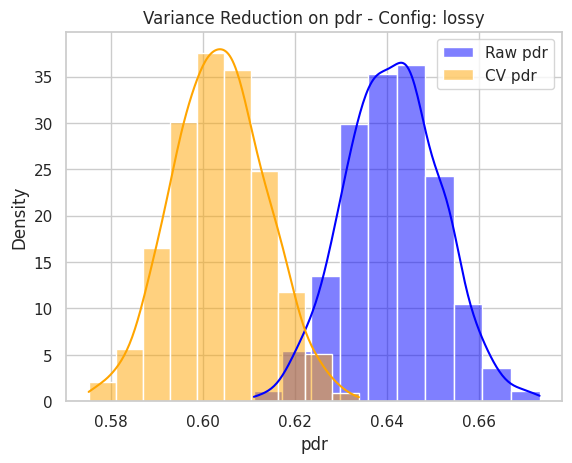

In [259]:
BINS = 10

sns.histplot(
    raw_metric,
    color="blue",
    label=f"Raw {METRIC_TO_ANALYZE}",
    kde=True,
    stat="density",
    bins=BINS,
)
sns.histplot(
    cv_metric,
    color="orange",
    label=f"CV {METRIC_TO_ANALYZE}",
    kde=True,
    stat="density",
    bins=BINS,
)
plt.legend()
plt.title(f"Variance Reduction on {METRIC_TO_ANALYZE} - Config: {CONFIG_TO_ANALYZE}")
plt.xlabel(METRIC_TO_ANALYZE)
plt.ylabel("Density")
plt.show()

## Main Analysis Batch 20251121_23-09-00


### Path configuration


In [260]:
# Path configuration
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251121_23-09-00").resolve()
TOPOLOGY_FOLDER_TO_ANALYZE = "random_20N"